# Day 2 - Cross-Validation

## Introduction

In Day 1, I used one validation set to evaluate the model.

But one validation split may not always give a reliable result because the score can change depending on how the data is split.

In this notebook, I will use Cross-Validation to evaluate the model several times using different parts of the data and compare the result with Day 1.

## Learning Objectives

In this notebook, I will:

- Understand how k-fold cross-validation works.
- Apply 5-fold cross-validation.
- Calculate the mean and standard deviation of the scores.
- Compare the result with the validation score from Day 1.
- Understand why stratified folds are useful for classification.

## What is Cross-Validation?

In Day 1, the model was evaluated using only one validation set.

With Cross-Validation, the data is divided into several parts called folds.

For 5-fold cross-validation, the model is trained 5 times. Each time, a different fold is used for validation and the other folds are used for training.

This gives more than one score instead of depending on a single result.

| Round | Training Folds | Validation Fold |
|------|----------------|-----------------|
| 1 | 2, 3, 4, 5 | 1 |
| 2 | 1, 3, 4, 5 | 2 |
| 3 | 1, 2, 4, 5 | 3 |
| 4 | 1, 2, 3, 5 | 4 |
| 5 | 1, 2, 3, 4 | 5 |

### Observation

Each part of the data is used once for validation.

At the end, I can compare the five scores and calculate their average to get a better idea about the model performance.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

In [3]:
## load dataset

df = pd.read_csv("healthcare-dataset-stroke-data.csv")

### Prepare Features and Target

I will use `stroke` as the target and the remaining columns as features..

In [4]:
df = df.drop("id", axis=1)

x = df.drop("stroke", axis=1)
y = df["stroke"]

### Keep the Test Set Separate

Before using cross-validation, I will keep 20% of the data as a test set.

This test set will not be used during cross-validation.

In [7]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", x_train.shape)
print("Test set:", x_test.shape)

Training set: (4088, 10)
Test set: (1022, 10)


### Observation

80% of the data will be used for cross-validation, while 20% is kept for the final test.

### Handle Missing Values

The `bmi` column has missing values, so I will fill them using the mean from the training data.

In [8]:
x_train = x_train.copy()
x_test = x_test.copy()

bmi_mean = x_train["bmi"].mean()

x_train["bmi"] = x_train["bmi"].fillna(bmi_mean)
x_test["bmi"] = x_test["bmi"].fillna(bmi_mean)

In [9]:
print("Train missing values:", x_train.isnull().sum().sum())
print("Test missing values:", x_test.isnull().sum().sum())

Train missing values: 0
Test missing values: 0


### Encode Categorical Features

Some columns contain text values, so I need to convert them into numerical values before training the model.

In [10]:
x_train_encoded = pd.get_dummies(x_train, drop_first=True)
x_test_encoded = pd.get_dummies(x_test, drop_first=True)

x_train_encoded, x_test_encoded = x_train_encoded.align(
    x_test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

In [17]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic", LogisticRegression(
        C=1.0,
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

### Observation

The data is now ready for model training and cross-validation.

# Hands-On Lab

## Step 1: 5-Fold Cross-Validation

For this step, I will use the Logistic Regression model from the previous work.

Instead of checking the model on one validation set, I will use 5-fold cross-validation and get five different F1-scores.

In [13]:
model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

In [15]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(
    model,
    x_train_scaled,
    y_train,
    cv=5,
    scoring="f1"
)

print("F1-scores:", cv_scores)

F1-scores: [0.19736842 0.23308271 0.23484848 0.23134328 0.27169811]


### Observation

The model produced five F1-scores, one for each fold.

The scores are not exactly the same because each fold uses a different part of the data for validation.

## Step 2: Mean and Standard Deviation

After getting the five F1-scores, I will calculate the mean to see the average model performance.

I will also calculate the standard deviation to see how much the scores change between folds.

In [18]:
mean = cv_scores.mean()
std = cv_scores.std()

print("Mean F1-score:", mean)
print("Standard Deviation:", std)

Mean F1-score: 0.2336682018915341
Standard Deviation: 0.023541832389179826


### Observation

The mean gives the average F1-score across the five folds.

The standard deviation shows how stable the model performance is across the different folds.

In [19]:
result= pd.DataFrame({
    "Fold": [1, 2, 3, 4, 5],
    "F1-score": cv_scores
})

result

,Fold,F1-score
0,1,0.197368
1,2,0.233083
2,3,0.234848
3,4,0.231343
4,5,0.271698


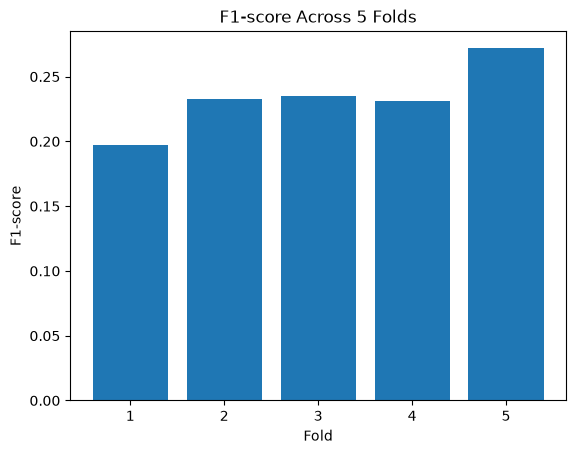

In [20]:
plt.bar(
result["Fold"],
    result["F1-score"]
)

plt.xlabel("Fold")
plt.ylabel("F1-score")
plt.title("F1-score Across 5 Folds")
plt.show()

### Observation

The F1-score is different across the five folds.

Fold 5 has the highest score, while Fold 1 has the lowest. This shows that the model performance can change depending on the validation data.

## Step 3: Compare the cross-validated estimate to the single-split score from Day 1 and explain any 
difference.

In Day 1, I evaluated the model using one validation split.

Now I will compare that score with the average score from 5-fold cross-validation.

In [23]:
day1_f = 0.24924012158054712
print("Day 1 Validation F1-score:", day1_f)
print("Cross-Validation Mean F1-score:", mean)

Day 1 Validation F1-score: 0.24924012158054712
Cross-Validation Mean F1-score: 0.2336682018915341


In [24]:
comparison = pd.DataFrame({
    "Method": ["Single Split , Day 1", "5-Fold Cross-Validation"],
    "F1-score": [day1_f, mean]
})

comparison

,Method,F1-score
0,"Single Split , Day 1",0.249240
1,5-Fold Cross-Validation,0.233668


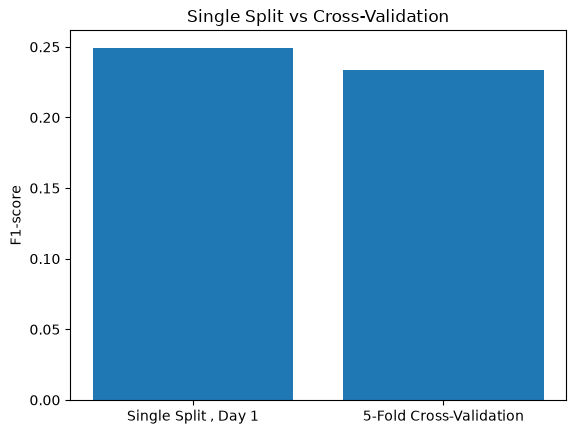

In [25]:
plt.bar(
    comparison["Method"],
    comparison["F1-score"]
)

plt.ylabel("F1-score")
plt.title("Single Split vs Cross-Validation")
plt.show()

### Observation

The single validation split from Day 1 gave a slightly higher F1-score than the 5-fold cross-validation average.

This difference happens because Day 1 used only one validation split, while cross-validation evaluated the model on several different folds.

The cross-validation result gives a better overall view of the model performance.

## Step 4: Stratified K-Fold

The stroke dataset is imbalanced because there are fewer stroke cases than non-stroke cases.

I will use StratifiedKFold to keep a similar class distribution in each fold.


In [27]:
from sklearn.model_selection import StratifiedKFold
stratified_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [28]:
stratified_scores = cross_val_score(
    model,
    x_train_encoded,
    y_train,
    cv=stratified_cv,
    scoring="f1"
)

print("Stratified F1-scores:", stratified_scores)

Stratified F1-scores: [0.21527778 0.24817518 0.2189781  0.22463768 0.23308271]


In [29]:
stratified_mean = stratified_scores.mean()
stratified_std = stratified_scores.std()

print("Mean F1-score:", stratified_mean)
print("Standard Deviation:", stratified_std)

Mean F1-score: 0.22803029007512965
Standard Deviation: 0.011725374835480112




The mean F1-score is about 0.228, and the standard deviation is small (0.012).

This means the model gave similar results across the stratified folds. Using StratifiedKFold is useful here because the stroke dataset is imbalanced and each fold keeps a similar class distribution.

### Observation

StratifiedKFold keeps a similar class distribution in each fold.

This is important for this dataset because stroke cases are much fewer than non-stroke cases.

## Conclusion

In this notebook, I used 5-fold cross-validation to evaluate the Logistic Regression model on different parts of the data.

The cross-validation result was slightly different from the single validation score in Day 1, which showed me that one split does not always give the full picture.

I also used StratifiedKFold because the stroke dataset is imbalanced. The results were close across the folds, with a mean F1-score of about 0.228 and a standard deviation of about 0.012.

Overall, cross-validation gave me a better idea of how consistent the model is across different splits of the data.